In [35]:
import lightgbm as lgb
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupKFold
from sklearn.metrics import ndcg_score

In [7]:
train_data = pd.read_parquet("/Users/margherita/Desktop/processed_data/train.parquet")
val_data = pd.read_parquet("/Users/margherita/Desktop/processed_data/val.parquet")
test_data = pd.read_parquet("/Users/margherita/Desktop/processed_data/test.parquet")

In [8]:
train_data.head()

,srch_id,date_time,site_id,visitor_location_country_id,visitor_hist_starrating,visitor_hist_adr_usd,prop_country_id,prop_id,prop_starrating,prop_review_score,...,price_diff_vs_visitor_hist,prop_click_rate,prop_book_rate,prop_mean_position,prop_median_price,prop_n_impressions,dest_click_rate,dest_book_rate,dest_median_price,relevance
0,1,2013-04-04 08:32:15,12,187,0.0,0.0,219,893,3,3.5,...,0.0,0.026854,0.676630,25.149622,118.000000,528,0.034722,0.758361,119.0,0
1,1,2013-04-04 08:32:15,12,187,0.0,0.0,219,10404,4,4.0,...,0.0,0.030528,0.609565,22.723791,129.000000,496,0.034722,0.758361,119.0,0
2,1,2013-04-04 08:32:15,12,187,0.0,0.0,219,21315,3,4.5,...,0.0,0.007273,0.556856,23.935345,168.920013,464,0.034722,0.758361,119.0,0
3,1,2013-04-04 08:32:15,12,187,0.0,0.0,219,27348,2,4.0,...,0.0,0.024100,0.591533,24.353403,65.059998,382,0.034722,0.758361,119.0,0
4,1,2013-04-04 08:32:15,12,187,0.0,0.0,219,29604,4,3.5,...,0.0,0.049560,0.637872,12.907802,118.000000,564,0.034722,0.758361,119.0,0


In [ ]:
# Sort all datasets by search ID 
# (all hotels belonging to the same search to be clustered together so it can compare them against each other)
train_data = train_data.sort_values('srch_id')
val_data = val_data.sort_values('srch_id')
test_data = test_data.sort_values('srch_id')

# Calculate the group sizes
# count exactly how many rows belong to each srch_id. So LightGBM knows where one search ends and the next begins.
train_groups = train_data.groupby('srch_id').size().values
val_groups = val_data.groupby('srch_id').size().values

print("Train group sizes:", train_groups)
print("Validation group sizes:", val_groups)

Train group sizes: [28 32  5 ... 24 28  6]
Validation group sizes: [28 29 34 ... 16  6 15]


In [29]:
categorical_features = ['site_id', 'visitor_location_country_id', 'prop_country_id', 'srch_destination_id']

for col in categorical_features:
    if col in train_data.columns and col in val_data.columns and col in test_data.columns:
        train_data[col] = train_data[col].astype(float).fillna(-1).astype(int).astype('category')
        val_data[col] = val_data[col].astype(float).fillna(-1).astype(int).astype('category')
        test_data[col] = test_data[col].astype(float).fillna(-1).astype(int).astype('category')

In [31]:
# Define features and target
features = [col for col in train_data.columns if col not in ['srch_id', 'prop_id', 'relevance', 
                                                             'date_time', 'click_bool', 'booking_bool',
                                                             'position', 'gross_bookings_usd']]
X_train = train_data[features]
y_train = train_data['relevance']
X_val = val_data[features]
y_val = val_data['relevance']
X_test = test_data[features]

In [ ]:
param_grid = {
    'num_leaves': [20, 31, 63],
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [100, 500, 1000]
}

n_iterations = 10
n_splits = 5

best_params = {}
best_cv_score = 0

X_full = X_train.copy()
y_full = y_train.copy()
groups_full = train_data['srch_id'].values

print("Starting hyperparameter tuning with GroupKFold cross-validation...")

for i in range(n_iterations):  
    params = {key: np.random.choice(values) for key, values in param_grid.items()}
    print(f"Iteration {i+1}/{n_iterations}, Testing parameters: {params}") 

    gkf = GroupKFold(n_splits=n_splits)
    fold_scores = []

    for train_idx, val_idx in gkf.split(X_full, y_full, groups=groups_full):
        X_train_fold, y_train_fold = X_full.iloc[train_idx], y_full.iloc[train_idx]
        X_val_fold, y_val_fold = X_full.iloc[val_idx], y_full.iloc[val_idx]

        train_fold_groups = X_train_fold.groupby(groups_full[train_idx]).size().values
        val_fold_groups = X_val_fold.groupby(groups_full[val_idx]).size().values

        ranker = lgb.LGBMRanker(objective='lambdarank', metric='ndcg', eval_at=[5], random_state=42, **params)
        ranker.fit(X_train_fold, y_train_fold, group=train_fold_groups,
            eval_set=[(X_val_fold, y_val_fold)],
            eval_group=[val_fold_groups],
            callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)]
        )

        best_iteration = ranker.best_iteration_
        fold_score = ranker.best_score_['valid_0']['ndcg@5']
        fold_scores.append(fold_score)

    avg_score = np.mean(fold_scores)
    print(f"Average NDCG@5 for iteration {i+1}: {avg_score:.4f}")
    if avg_score > best_cv_score:
        best_cv_score = avg_score
        best_params = params
        print(f"New best parameters found: {best_params} with NDCG@5: {best_cv_score:.4f}")
    
print(f"Best hyperparameters: {best_params} with NDCG@5: {best_cv_score:.4f}")

Starting hyperparameter tuning with GroupKFold cross-validation...
Iteration 1/10, Testing parameters: {'num_leaves': np.int64(31), 'learning_rate': np.float64(0.05), 'n_estimators': np.int64(500)}


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.384747 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 14902
[LightGBM] [Info] Number of data points in the train set: 3372456, number of used features: 57


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.925446 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 14956
[LightGBM] [Info] Number of data points in the train set: 3372456, number of used features: 57


...

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.081298 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 14961
[LightGBM] [Info] Number of data points in the train set: 3372456, number of used features: 57


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.211980 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 14958
[LightGBM] [Info] Number of data points in the train set: 3372456, number of used features: 57


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.910054 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 14946
[LightGBM] [Info] Number of data points in the train set: 3372452, number of used features: 57
Average NDCG@5 for iteration 10: 0.4796
Best hyperparameters: {'num_leaves': np.int64(20), 'learning_rate': np.float64(0.2), 'n_estimators': np.int64(1000)} with NDCG@5: 0.4810


In [40]:
# Initialize the LGBMRanker with the specified parameters
ranker = lgb.LGBMRanker(
    objective='lambdarank',
    metric='ndcg',
    eval_at=[5],
    random_state=42,
    importance_type='gain',
    **best_params
)

# Fit the model with early stopping
ranker.fit(
    X_train, y_train,
    group=train_groups,
    eval_set=[(X_val, y_val)],
    eval_group=[val_groups],
    callbacks=[lgb.early_stopping(stopping_rounds=100), lgb.log_evaluation(period=50)]
)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.218429 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 14880
[LightGBM] [Info] Number of data points in the train set: 4215569, number of used features: 57
Training until validation scores don't improve for 100 rounds
[50]	valid_0's ndcg@5: 0.372062
[100]	valid_0's ndcg@5: 0.375731
[150]	valid_0's ndcg@5: 0.37767
[200]	valid_0's ndcg@5: 0.377002
[250]	valid_0's ndcg@5: 0.375888
Early stopping, best iteration is:
[151]	valid_0's ndcg@5: 0.378032


LGBMRanker(eval_at=[5], importance_type='gain', learning_rate=np.float64(0.2),
           metric='ndcg', n_estimators=np.int64(1000), num_leaves=np.int64(20),
           objective='lambdarank', random_state=42)

In [34]:
# Make predictions on the test set
X_test = test_data[features]
test_data['predicted_score'] = ranker.predict(X_test)

# Sort the test data by Search ID, then by the predicted score descending
# This puts the highest scored hotels at the top for each search
test_predictions = test_data.sort_values(['srch_id', 'predicted_score'], ascending=[True, False])

# Keep only the necessary columns and rename them to match the required format[cite: 2]
submission = test_predictions[['srch_id', 'prop_id']].copy()
submission.columns = ['SearchId', 'PropertyId']

# Save to CSV without the index
submission.to_csv('kaggle_submission.csv', index=False)
print("Submission saved to kaggle_submission.csv!")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


Submission saved to kaggle_submission.csv!


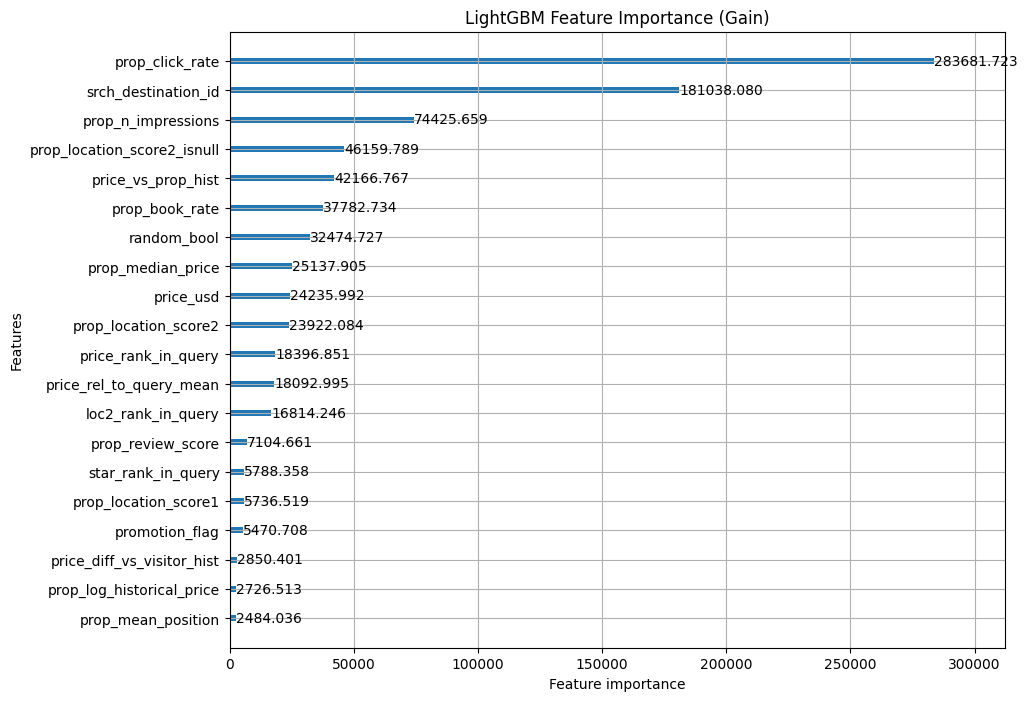

In [41]:
import matplotlib.pyplot as plt

# Tell LightGBM to plot the top 20 most important features
lgb.plot_importance(ranker, max_num_features=20, figsize=(10, 8), importance_type='gain')
plt.title("LightGBM Feature Importance (Gain)")
plt.show()